
# Quantum vs. Classical Correlations in Dijet Hadron Multiplicities:
# A Finite-Statistics Methodology Note

This note works through the full chain for measuring mutual information
(MI) between back-to-back jets from hadron multiplicity distributions, and
establishing whether an observed correlation could be a genuine quantum
signature or is fully explained by classical physics plus finite-sample
statistical bias.

**Contents:**
1. Physics motivation
2. The observable: MI, conditional entropy, and the quantum witness
3. The statistical problem: finite-sample bias
4. Toy Monte Carlo test bed (demonstrates the bias concretely)
5. Corrections: Miller–Madow and shuffle-subtraction
6. The rigorous fix: NSB Bayesian entropy estimation
7. Putting it together: quantum-signal detection sensitivity
8. Summary and recommendations for the real STAR dijet analysis



## 1. Physics motivation

Take a back-to-back dijet event (e.g. from $e^+e^-$, DIS, or $pp$
collisions at RHIC/STAR). Treat jet $A$ and jet $B$ as the two subsystems
of a bipartite system whose "state" is accessed only through observed
hadron multiplicities, via **local parton–hadron duality (LPHD)**: the
hadron multiplicity distribution stands in for the underlying parton
Fock-state distribution.

**The Schmidt-decomposition ansatz** (Kharzeev–Levin; Peschanski–Seki):
if each Fock/parton-number sector $n$ carries probability $P(n)$, and the
reduced density matrix of a jet is diagonal in $n$, then the entanglement
entropy of that jet reduces to the **Shannon entropy of its hadron
multiplicity distribution**:
$$S_A = -\sum_n P_A(n)\ln P_A(n)$$
and likewise for $S_B$. This turns a genuinely quantum quantity
(entanglement entropy) into something directly measurable from ordinary
multiplicity counting — the whole program rests on this ansatz.

**The physics question:** by additionally measuring the *joint*
multiplicity distribution $P_{AB}(n_A,n_B)$ across both jets in the same
event, we can construct the mutual information $I(A:B)$ between the two
jets (defined in Section 2). A large enough MI, in the right combination
with the individual entropies, would signal correlations between the jets
that cannot be explained by any classical joint probability distribution
— i.e. a genuine quantum (entanglement) signature surviving from the
partonic state through hadronization, rather than an ordinary classical
correlation (e.g. shared color flow, momentum conservation, or other
QCD-driven but fundamentally classical correlations).

**Why this is subtle in practice:** any such claim is only as good as (a)
correctly separating genuine quantum correlation from unavoidable
classical correlation, and (b) correctly accounting for the finite size of
real data samples, since MI estimated from a finite event sample is
**always statistically biased**, and — as we'll show — biased in exactly
the direction that could be mistaken for a quantum excess if not handled
carefully. This note works through both issues end to end.



## 2. The observable: MI, conditional entropy, and the quantum witness

From the per-jet and joint hadron-multiplicity distributions we can build
three entropies and two derived quantities:

$$S_A,\quad S_B,\quad S_{AB} \qquad\Longrightarrow\qquad
I(A:B) = S_A+S_B-S_{AB}, \qquad S(B|A) = S_{AB}-S_A$$

**Mutual information alone cannot distinguish quantum from classical.**
$I(A:B)>0$ just means the jets are correlated *somehow* — a purely
classical joint distribution (shared color flow, energy-momentum
conservation, any ordinary QCD dynamics) also gives nonzero MI. A sharper
diagnostic is needed.

**The sharper test: conditional entropy negativity.** For *any* classical
discrete probability distribution, Shannon conditional entropy obeys
$$S(B|A) = S_{AB}-S_A \;\geq\; 0 \qquad\text{(always, classically)}$$
This is the classical subadditivity of Shannon entropy — not an assumption
about any particular physical model. Only the *quantum* (von Neumann)
conditional entropy can go negative, and only for entangled states. So
**$S(B|A)<0$ is a hard classical impossibility**, and observing it (at
sufficient statistical significance) would be direct evidence that the
jets cannot be described by a classical joint probability distribution —
i.e. a genuine quantum signature. Equivalently, in terms of MI alone:
$$I(A:B) \;>\; \min(S_A,\,S_B) \qquad\Longleftrightarrow\qquad S(B|A)<0 \text{ or } S(A|B)<0$$
so MI exceeding the smaller of the two marginal entropies is the same
statement in a different form. Both directions ($S(B|A)$ and $S(A|B)$) are
worth checking independently, since conditional entropy is not symmetric.

**What this test can *not* do: genuine quantum discord.** True
(Ollivier–Zurek) quantum discord is defined by optimizing conditional
entropy over *quantum measurement bases* — non-commuting projective
measurements that don't reduce to simply reading off a classical value.
Hadron-multiplicity data $(N_A,N_B)$ is, by construction, a classical
joint distribution (a histogram). For any classical joint distribution,
the optimal "measurement" on $B$ is trivially just observing $N_B$
exactly, which makes the classical-correlation piece $J(A:B)$ equal to the
*full* $I(A:B)$ exactly — so discord $D=I-J\equiv 0$ identically, for any
classical distribution, with no exception. Extracting a genuinely nonzero
discord requires actual quantum-state tomography (e.g. Kong's proposed/measured
$\Lambda\bar\Lambda$ spin-density-matrix channel), not multiplicity
counting. **The conditional-entropy-negativity test above is therefore the
correct and complete witness available from this kind of data** — the
rest of this note is about measuring it reliably.



## 3. The statistical problem: finite-sample bias

Every quantity above is estimated from a finite event sample, and the
naive ("plug-in") entropy estimator has a **systematic, structural bias**
that turns out to point in exactly the dangerous direction for this
measurement.

**Where the bias comes from.** The naive estimator replaces true
probabilities $p_i$ with empirical frequencies $\hat p_i=n_i/N$:
$$\hat S = -\sum_i \hat p_i \ln \hat p_i$$
Because $x\ln x$ is convex (equivalently $-x\ln x$ is concave), Jensen's
inequality guarantees
$$\langle \hat S \rangle \;<\; S_{\rm true} \qquad \text{for any finite } N$$
— the plug-in estimator always underestimates entropy. This isn't a
numerical artifact; with only $N$ draws you can never fully resolve a
distribution's tails, and that missing resolution always looks like *less*
apparent randomness than there truly is.

**Leading-order size of the effect** (Miller 1955, Madow), for a
distribution over $K$ possible outcomes:
$$\langle \hat S \rangle \approx S_{\rm true} - \frac{K-1}{2N}$$
Fewer events ($N$ small) or finer binning ($K$ large) both make the
downward bias worse.

**Why this flips sign and biases $I(A:B)$ *upward*.** Combining the
individual biases of $\hat S_A,\hat S_B,\hat S_{AB}$ with correct signs:
$$\langle\hat I\rangle \;\approx\; I_{\rm true} + \frac{(K_{AB}-1)-(K_A-1)-(K_B-1)}{2N}
= I_{\rm true} + \frac{K_{AB}-K_A-K_B+1}{2N}$$
The joint distribution lives in a much larger space than either marginal
alone, so $\hat S_{AB}$ suffers a *much larger* downward bias than
$\hat S_A+\hat S_B$ does — and since $S_{AB}$ enters with a **minus** sign,
its extra negative bias flips into a **positive** bias on $\hat I$. In the
extreme case $N \ll K_A K_B$ (badly undersampled joint histogram), this
produces large *phantom* apparent mutual information even for truly
independent variables — sampling noise alone can masquerade as a real
correlation, and by the same mechanism can masquerade as evidence for the
"quantum" side of the $S(B|A)<0$ test above if not corrected.

*(A commonly-quoted shortcut version of this formula is
$(K_A-1)(K_B-1)/(2N)$ — this is not a different formula, it's the exact
expression above evaluated under the extra assumption $K_{AB}=K_AK_B$,
i.e. a fully and uniformly occupied joint space. That assumption only
holds for independent variables; for correlated data, the observed
$K_{AB}$ is much smaller than $K_AK_B$ [the joint distribution
concentrates on a narrow ridge rather than filling the full grid], so
this shortcut badly *overestimates* the bias. Section 5 hits this exact
pitfall directly.)*

**Practical consequence:** comparing the same underlying physics across
data samples of different size — different STAR running periods, different
luminosity, different jet-cone or multiplicity binning choices — will
report systematically different central MI (and $S(B|A)$) values purely
from this effect, with zero change in the actual QCD physics. Sections 4–6
demonstrate this concretely with a toy model and work through three ways
to correct for it; Section 7 turns the corrected, best-behaved estimator
into a quantitative statement about how large a genuine quantum signal
would need to be, at a given event count, to be distinguishable from this
bias.



## 4. Toy Monte Carlo test bed

To demonstrate the bias concretely and validate corrections against a
known ground truth, we use a controlled toy model: two back-to-back jets,
$A$ and $B$, with a shared latent hard-process fluctuation $\Lambda$ (e.g.
fluctuating parton virtuality / initial-state energy scale) drawn from a
Gamma distribution. Conditional on $\Lambda$, each jet's hadron
multiplicity is Poisson distributed:
$$\Lambda \sim \mathrm{Gamma}(k,\theta), \qquad
N_A\,|\,\Lambda \sim \mathrm{Poisson}(\Lambda), \qquad
N_B\,|\,\Lambda \sim \mathrm{Poisson}(c\,\Lambda)$$
Marginalizing over $\Lambda$ gives each jet a **Negative Binomial**
multiplicity distribution (the standard KNO-like form used for hadron
multiplicities), and the shared $\Lambda$ induces a genuine — but purely
**classical** — correlation between $N_A$ and $N_B$, i.e. $I_{\rm true}>0$
with $S(B|A)_{\rm true}$ solidly positive, exactly as required classically.
This is a convenient sandbox: we know the true joint distribution (to
arbitrary precision, from a huge reference sample), so we can measure the
*bias* of any estimator directly, and later measure how large a *genuine*
quantum excess would need to be to be distinguishable from this classical
baseline's own statistical noise.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln, digamma, polygamma

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

COLOR_SMALL = '#d62728'   # red
COLOR_LARGE = '#1f77b4'   # blue
COLOR_REF   = '#2ca02c'   # green
COLOR_NAIVE = '#d62728'
COLOR_MM    = '#ff7f0e'
COLOR_SH    = '#1f77b4'
COLOR_NSB   = '#9467bd'   # purple

rng = np.random.default_rng(42)

# ---------------------------------------------------------------------
# Toy event generator: shared Gamma latent variable -> correlated Poisson
# hadron multiplicities in jet A and jet B.
# ---------------------------------------------------------------------
def generate_events(n_events, k=3.0, theta=8.0, c=0.9, rng=rng):
    '''
    Generate n_events pairs (N_A, N_B) of hadron multiplicities.

    k, theta : shape/scale of the shared Gamma latent variable Lambda
    c        : correlation knob, 0 < c <= 1. c=1 -> maximal shared response.
               c=0 would make B independent of A (Poisson(0) -> always 0,
               so keep c>0 and interpret as relative response strength).
    '''
    lam = rng.gamma(shape=k, scale=theta, size=n_events)
    n_a = rng.poisson(lam)
    n_b = rng.poisson(c * lam)
    return n_a, n_b

# quick sanity check
na, nb = generate_events(20000)
print(f"<N_A> = {na.mean():.2f}, <N_B> = {nb.mean():.2f}, corr(N_A,N_B) = {np.corrcoef(na, nb)[0,1]:.3f}")


<N_A> = 24.12, <N_B> = 21.70, corr(N_A,N_B) = 0.884



### Naive plug-in entropy / MI estimator (implements Section 2's formulas)

$$\hat S_X = -\sum_i \hat p_i \ln \hat p_i, \qquad \hat p_i = n_i/N \qquad\qquad
\hat I(A:B) = \hat S_A + \hat S_B - \hat S_{AB}$$

All entropies are computed directly from empirical histograms of the
integer-valued multiplicities (no smoothing).


In [2]:

def shannon_entropy(counts):
    '''Plug-in Shannon entropy (nats) from an array of raw category counts.'''
    counts = np.asarray(counts, dtype=float)
    counts = counts[counts > 0]
    p = counts / counts.sum()
    return -np.sum(p * np.log(p))

def entropies_from_samples(n_a, n_b):
    '''Return (S_A, S_B, S_AB, K_A, K_B, K_AB, N) plug-in estimates.'''
    N = len(n_a)

    # marginal histograms
    vals_a, counts_a = np.unique(n_a, return_counts=True)
    vals_b, counts_b = np.unique(n_b, return_counts=True)
    S_A = shannon_entropy(counts_a)
    S_B = shannon_entropy(counts_b)
    K_A, K_B = len(vals_a), len(vals_b)

    # joint histogram (2D)
    pairs = np.stack([n_a, n_b], axis=1)
    _, joint_counts = np.unique(pairs, axis=0, return_counts=True)
    S_AB = shannon_entropy(joint_counts)
    K_AB = len(joint_counts)

    return S_A, S_B, S_AB, K_A, K_B, K_AB, N

def naive_MI(n_a, n_b):
    S_A, S_B, S_AB, K_A, K_B, K_AB, N = entropies_from_samples(n_a, n_b)
    I = S_A + S_B - S_AB
    return I, dict(S_A=S_A, S_B=S_B, S_AB=S_AB, K_A=K_A, K_B=K_B, K_AB=K_AB, N=N)



### Demonstration: two samples, same true distribution, different size

Generate a "small" event sample (e.g. a single limited run / low-luminosity
STAR-like dataset) and a "large" event sample (high-statistics dataset),
drawn from the **exact same underlying physics** (same k, theta, c). We
also build a very large reference sample to pin down $I_{\rm true}$.


In [3]:

K_SHAPE, THETA_SCALE, C_CORR = 3.0, 8.0, 0.9

N_SMALL   = 500
N_LARGE   = 200_000
N_REF     = 5_000_000   # reference "truth" sample

na_small, nb_small = generate_events(N_SMALL,  K_SHAPE, THETA_SCALE, C_CORR)
na_large, nb_large = generate_events(N_LARGE,  K_SHAPE, THETA_SCALE, C_CORR)
na_ref,   nb_ref   = generate_events(N_REF,    K_SHAPE, THETA_SCALE, C_CORR)

I_small, info_small = naive_MI(na_small, nb_small)
I_large, info_large = naive_MI(na_large, nb_large)
I_ref,   info_ref   = naive_MI(na_ref,   nb_ref)

print(f"{'sample':>8} | {'N':>10} | {'K_A':>5} {'K_B':>5} {'K_AB':>6} | {'I_naive (nats)':>15}")
print("-"*65)
print(f"{'small':>8} | {info_small['N']:>10} | {info_small['K_A']:>5} {info_small['K_B']:>5} {info_small['K_AB']:>6} | {I_small:>15.4f}")
print(f"{'large':>8} | {info_large['N']:>10} | {info_large['K_A']:>5} {info_large['K_B']:>5} {info_large['K_AB']:>6} | {I_large:>15.4f}")
print(f"{'ref':>8} | {info_ref['N']:>10} | {info_ref['K_A']:>5} {info_ref['K_B']:>5} {info_ref['K_AB']:>6} | {I_ref:>15.4f}  <-- ~I_true")


  sample |          N |   K_A   K_B   K_AB |  I_naive (nats)
-----------------------------------------------------------------
   small |        500 |    67    60    390 |          1.7424
   large |     200000 |   129   113   3949 |          0.7463
     ref |    5000000 |   159   147   7022 |          0.7329  <-- ~I_true



You should see $\hat I_{\rm small} > \hat I_{\rm large} \approx \hat I_{\rm ref} \equiv I_{\rm true}$ —
**the same physics, analyzed with fewer events, reports a systematically larger MI.**
This is the bias predicted in Section 3, not a change in physics.

### Why: visualizing the marginals and the joint distribution

The bias comes entirely from how well-populated the joint histogram is.
Below: (top) the marginal hadron-multiplicity distributions $P_A(n)$,
overlaid for the small, large, and reference samples — these look
reasonably similar even at $N=500$ because there are only $O(10^2)$ bins
to fill. (bottom) the 2D joint histograms $P_{AB}(n_A,n_B)$ for the same
three samples on the same axes/color scale — this is where the difference
is dramatic: at $N=500$ the joint plane is almost empty (a handful of
scattered points), while at $N=5\times10^6$ it is a smooth, fully-resolved
correlated ridge. A sparse, "salt-and-pepper" joint histogram is exactly
what drives $\hat S_{AB}$ artificially low, and hence $\hat I$ artificially
high.


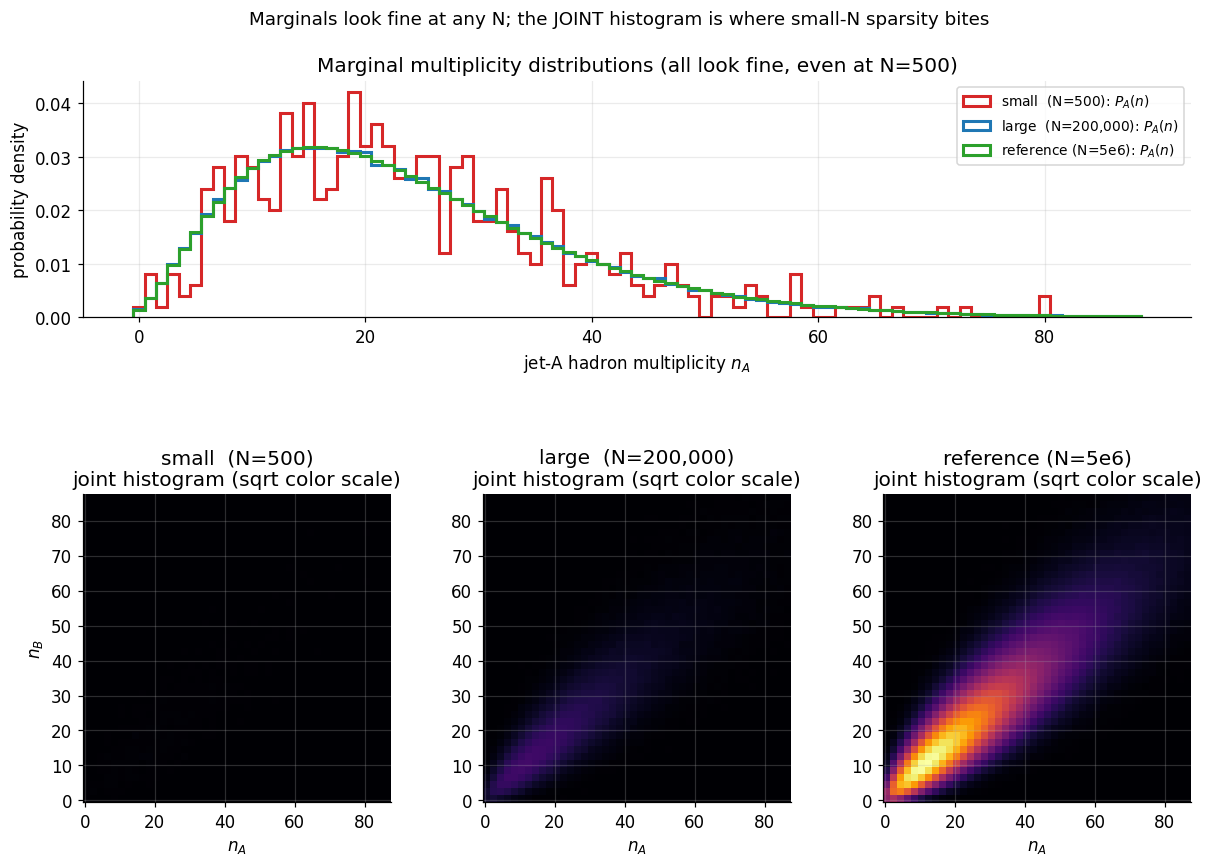

In [4]:

fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.3], hspace=0.65, wspace=0.3,
                       top=0.90, bottom=0.08)

samples = [
    ('small  (N=500)',      na_small, nb_small, COLOR_SMALL),
    ('large  (N=200,000)',  na_large, nb_large, COLOR_LARGE),
    ('reference (N=5e6)',   na_ref,   nb_ref,   COLOR_REF),
]

# --- top row: overlaid marginal P_A(n) ---
ax_marg = fig.add_subplot(gs[0, :])
bins = np.arange(0, 90) - 0.5
for label, na_, nb_, color in samples:
    ax_marg.hist(na_, bins=bins, density=True, histtype='step', lw=2,
                 color=color, label=f'{label}: $P_A(n)$')
ax_marg.set_xlabel(r'jet-A hadron multiplicity $n_A$')
ax_marg.set_ylabel('probability density')
ax_marg.set_title('Marginal multiplicity distributions (all look fine, even at N=500)')
ax_marg.legend(fontsize=9)

# --- bottom row: joint histograms side by side, same color scale ---
edges = np.arange(0, 90, 2) - 0.5
vmax = 0
hists = []
for label, na_, nb_, color in samples:
    h, xe, ye = np.histogram2d(na_, nb_, bins=[edges, edges])
    hists.append(h)
    vmax = max(vmax, h.max())

for i, ((label, na_, nb_, color), h) in enumerate(zip(samples, hists)):
    ax = fig.add_subplot(gs[1, i])
    im = ax.pcolormesh(edges, edges, np.sqrt(h.T), cmap='inferno',
                        vmin=0, vmax=np.sqrt(vmax), shading='auto')
    ax.set_xlabel(r'$n_A$')
    if i == 0:
        ax.set_ylabel(r'$n_B$')
    ax.set_title(f'{label}\njoint histogram (sqrt color scale)')
    ax.set_aspect('equal')

fig.suptitle('Marginals look fine at any N; the JOINT histogram is where small-N sparsity bites',
             y=0.98, fontsize=12)
plt.show()



### Bias vs. sample size scan

Repeat the naive estimate over a range of $N$ (with several repetitions per
$N$ to see the scatter), and plot $\hat I_{\rm naive}$ vs $1/N$. The
Miller–Madow prediction is a straight line in $1/N$ with slope
$(K_A-1)(K_B-1)/2$ (using $K$'s measured at each $N$, since $K$ itself grows
with $N$ until it saturates at the true support size).


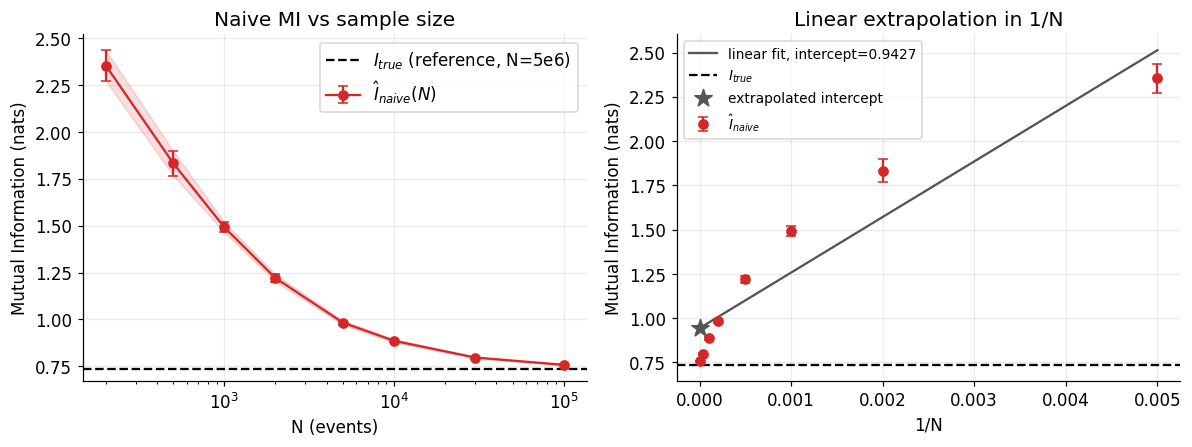

Extrapolated (1/N -> 0) intercept: 0.9427 nats   vs   I_true (reference): 0.7329 nats


In [5]:

N_grid = np.array([200, 500, 1000, 2000, 5000, 10000, 30000, 100000])
n_repeats = 15

I_means, I_stds = [], []
for N in N_grid:
    Is = []
    for _ in range(n_repeats):
        na, nb = generate_events(N, K_SHAPE, THETA_SCALE, C_CORR)
        I, _ = naive_MI(na, nb)
        Is.append(I)
    I_means.append(np.mean(Is))
    I_stds.append(np.std(Is))

I_means = np.array(I_means)
I_stds  = np.array(I_stds)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ax[0].fill_between(N_grid, I_means - I_stds, I_means + I_stds, color=COLOR_NAIVE, alpha=0.15)
ax[0].errorbar(N_grid, I_means, yerr=I_stds, fmt='o-', capsize=3, color=COLOR_NAIVE,
               label=r'$\hat I_{naive}(N)$')
ax[0].axhline(I_ref, color='k', ls='--', lw=1.5, label=r'$I_{true}$ (reference, N=5e6)')
ax[0].set_xscale('log')
ax[0].set_xlabel('N (events)')
ax[0].set_ylabel('Mutual Information (nats)')
ax[0].set_title('Naive MI vs sample size')
ax[0].legend()

ax[1].errorbar(1.0/N_grid, I_means, yerr=I_stds, fmt='o', capsize=3, color=COLOR_NAIVE,
               label=r'$\hat I_{naive}$')
# linear fit in 1/N to extrapolate to N->infinity (intercept = bias-free estimate)
coeffs = np.polyfit(1.0/N_grid, I_means, 1)
x_fit = np.linspace(0, (1.0/N_grid).max(), 50)
ax[1].plot(x_fit, np.polyval(coeffs, x_fit), '-', color='#555555',
           label=f'linear fit, intercept={coeffs[1]:.4f}')
ax[1].axhline(I_ref, color='k', ls='--', lw=1.5, label=r'$I_{true}$')
ax[1].scatter([0], [coeffs[1]], color='#555555', zorder=5, marker='*', s=140,
              label='extrapolated intercept')
ax[1].set_xlabel('1/N')
ax[1].set_ylabel('Mutual Information (nats)')
ax[1].set_title('Linear extrapolation in 1/N')
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Extrapolated (1/N -> 0) intercept: {coeffs[1]:.4f} nats   vs   I_true (reference): {I_ref:.4f} nats")



The left panel shows the systematic downward drift (bias shrinking) as $N$
grows, converging toward the flat reference line. The right panel shows the
expected near-linear behavior in $1/N$: the intercept of that line is a
cheap, model-independent estimate of the bias-corrected / true MI, and it
should land close to the reference value.



## 5. Corrections: Miller–Madow and shuffle-subtraction

### (a) Miller–Madow correction

The exact leading-order Miller–Madow correction applies the $-(K-1)/(2N)$
term to *each* of $S_A, S_B, S_{AB}$ separately and combines them:

$$\hat I_{MM} = \hat I_{\rm naive} - \frac{(K_{AB}-1)-(K_A-1)-(K_B-1)}{2N}
= \hat I_{\rm naive} - \frac{K_{AB}-K_A-K_B+1}{2N}$$

**Important:** $K_{AB}$ here must be the *actually observed* number of
occupied joint bins, not the product $K_A K_B$. For independent variables
those are close, but for correlated variables (our case, by construction)
the joint distribution concentrates on a narrow ridge and $K_{AB}\ll K_AK_B$.
Using the product in place of the observed $K_{AB}$ — an easy mistake —
wildly overcorrects and can drive $\hat I_{MM}$ negative.

### (b) Shuffle-subtraction (label-permutation null)

Randomly permute the $B$-jet labels relative to the $A$-jet labels *within
the same sample* (same $N$, same marginals, same $K_A,K_B,K_{AB}^{\max}$
support structure), which destroys any true correlation
($I_{\rm true,shuffled}=0$ by construction) but reproduces the *same*
finite-sample bias. Averaging over many shuffles gives a direct empirical
estimate of the bias to subtract:

$$\hat I_{\rm corrected} = \hat I_{\rm naive} - \left\langle \hat I_{\rm shuffled}\right\rangle$$

This makes no asymptotic assumption and remains reliable even when
$N \lesssim K_A K_B$ (badly undersampled joint histogram), where
Miller–Madow starts to break down. It has its own bias, however: shuffling
spreads the joint distribution over *more* bins than the true correlated
data occupies (since correlation concentrates probability onto a narrow
ridge, and destroying the correlation spreads it back out over the full
product space), so the shuffled surrogate is *more* undersampled than the
real data at the same $N$. That means shuffle-subtraction tends to
systematically **overestimate** the bias, and **overcorrect** — pulling
$\hat I_{\rm corrected}$ below $I_{\rm true}$ when the true correlation is strong.


In [6]:

def miller_madow_MI(n_a, n_b):
    '''Correct Miller-Madow: uses the ACTUAL observed K_AB, not K_A*K_B.'''
    S_A, S_B, S_AB, K_A, K_B, K_AB, N = entropies_from_samples(n_a, n_b)
    I_naive = S_A + S_B - S_AB
    bias = (K_AB - K_A - K_B + 1) / (2.0 * N)
    return I_naive - bias, I_naive, bias

def shuffle_correction_MI(n_a, n_b, n_shuffles=100, rng=rng):
    '''Estimate the finite-sample bias by permuting B-labels relative to A.'''
    I_naive, _ = naive_MI(n_a, n_b)
    n_b = np.asarray(n_b)
    I_shuffled = np.empty(n_shuffles)
    for i in range(n_shuffles):
        perm = rng.permutation(len(n_b))
        I_shuffled[i], _ = naive_MI(n_a, n_b[perm])
    bias_est = I_shuffled.mean()
    bias_err = I_shuffled.std(ddof=1) / np.sqrt(n_shuffles)
    return I_naive - bias_est, I_naive, bias_est, bias_err


In [7]:

print(f"{'N':>8} | {'I_naive':>9} | {'I_MM':>9} | {'I_shuffle':>10} | {'I_true(ref)':>11}")
print("-"*62)

results = []
for N in [200, 500, 1000, 2000, 5000, 20000]:
    na, nb = generate_events(N, K_SHAPE, THETA_SCALE, C_CORR)
    I_naive, _ = naive_MI(na, nb)
    I_mm, _, _ = miller_madow_MI(na, nb)
    I_sh, _, bias_sh, bias_sh_err = shuffle_correction_MI(na, nb, n_shuffles=200)
    results.append((N, I_naive, I_mm, I_sh))
    print(f"{N:>8} | {I_naive:>9.4f} | {I_mm:>9.4f} | {I_sh:>10.4f} | {I_ref:>11.4f}")


       N |   I_naive |      I_MM |  I_shuffle | I_true(ref)
--------------------------------------------------------------
     200 |    2.2764 |    2.0889 |     0.0657 |      0.7329


     500 |    1.8694 |    1.6014 |     0.1436 |      0.7329


    1000 |    1.4271 |    1.1756 |     0.2422 |      0.7329


    2000 |    1.1873 |    0.9866 |     0.3809 |      0.7329


    5000 |    0.9766 |    0.8539 |     0.5592 |      0.7329


   20000 |    0.8259 |    0.7750 |     0.6792 |      0.7329



With the fixed Miller–Madow formula (using observed $K_{AB}$), both
corrections pull the small-$N$ estimates much closer to $I_{\rm true}$
than the naive value — and stay sane (no more diving negative). Neither
lands exactly on $I_{\rm true}$ at very small $N$: Miller–Madow is only a
first-order truncation of the true bias expansion, and shuffle-subtraction
tends to *overcorrect* when the true correlation is strong (see
explanation above). Both effects shrink as $N$ grows.

### Visualizing the shuffle-null distribution

The shuffle procedure gives you more than a bias correction — the spread
of $\hat I_{\rm shuffled}$ over many permutations *is* the null
distribution for "$I_{\rm true}=0$" at this $N$ and this binning. Plotting
$\hat I_{\rm naive}$ against that null distribution is a direct visual
significance check: if $\hat I_{\rm naive}$ sits well outside the null
histogram, the correlation signal is real; if it sits inside, you cannot
yet distinguish it from pure sampling bias.


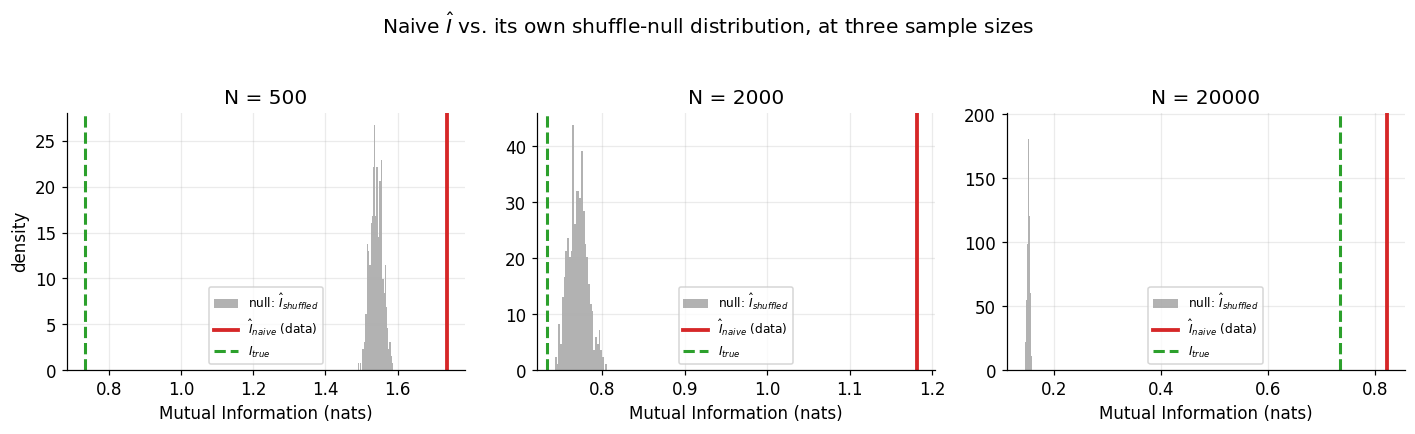

In [8]:

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=False)

for ax, N in zip(axes, [500, 2000, 20000]):
    na, nb = generate_events(N, K_SHAPE, THETA_SCALE, C_CORR)
    I_naive, _ = naive_MI(na, nb)
    n_shuffles = 400
    I_null = np.empty(n_shuffles)
    nb_arr = np.asarray(nb)
    for i in range(n_shuffles):
        perm = rng.permutation(len(nb_arr))
        I_null[i], _ = naive_MI(na, nb_arr[perm])

    ax.hist(I_null, bins=30, color='gray', alpha=0.6, density=True,
            label=r'null: $\hat I_{shuffled}$')
    ax.axvline(I_naive, color=COLOR_NAIVE, lw=2.5, label=r'$\hat I_{naive}$ (data)')
    ax.axvline(I_ref, color=COLOR_REF, lw=2, ls='--', label=r'$I_{true}$')
    ax.set_xlabel('Mutual Information (nats)')
    ax.set_title(f'N = {N}')
    if ax is axes[0]:
        ax.set_ylabel('density')
    ax.legend(fontsize=8)

plt.suptitle(r'Naive $\hat I$ vs. its own shuffle-null distribution, at three sample sizes', y=1.03)
plt.tight_layout()
plt.show()



Notice how, at $N=500$, the null distribution itself is already centered
well above zero (pure bias) — the naive value sits close to or inside this
null cloud, so on its own it would *not* be significant evidence of
correlation, even though we know by construction that the jets are truly
correlated. By $N=20000$ the null has collapsed toward zero and the naive
value clearly separates from it.

### Visual summary: naive vs. corrected MI across sample sizes


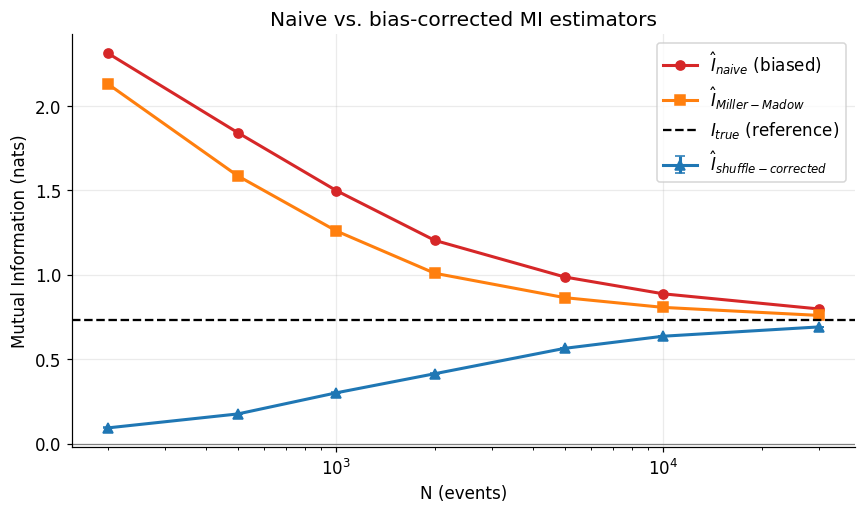

In [9]:

N_grid2 = np.array([200, 500, 1000, 2000, 5000, 10000, 30000])
n_rep = 20

I_naive_arr, I_mm_arr, I_sh_arr = [], [], []
I_sh_err_arr = []

for N in N_grid2:
    naive_reps, mm_reps, sh_reps, sh_err_reps = [], [], [], []
    for _ in range(n_rep):
        na, nb = generate_events(N, K_SHAPE, THETA_SCALE, C_CORR)
        I_naive, _ = naive_MI(na, nb)
        I_mm, _, _ = miller_madow_MI(na, nb)
        I_sh, _, _, bias_err = shuffle_correction_MI(na, nb, n_shuffles=60)
        naive_reps.append(I_naive)
        mm_reps.append(I_mm)
        sh_reps.append(I_sh)
        sh_err_reps.append(bias_err)
    I_naive_arr.append(np.mean(naive_reps))
    I_mm_arr.append(np.mean(mm_reps))
    I_sh_arr.append(np.mean(sh_reps))
    I_sh_err_arr.append(np.mean(sh_err_reps))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(N_grid2, I_naive_arr, 'o-', label=r'$\hat I_{naive}$ (biased)', color=COLOR_NAIVE, lw=2)
ax.plot(N_grid2, I_mm_arr,   's-', label=r'$\hat I_{Miller-Madow}$', color=COLOR_MM, lw=2)
ax.errorbar(N_grid2, I_sh_arr, yerr=I_sh_err_arr, fmt='^-', label=r'$\hat I_{shuffle-corrected}$',
            color=COLOR_SH, capsize=3, lw=2)
ax.axhline(I_ref, color='k', ls='--', lw=1.5, label=r'$I_{true}$ (reference)')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('N (events)')
ax.set_ylabel('Mutual Information (nats)')
ax.set_title('Naive vs. bias-corrected MI estimators')
ax.legend()
plt.tight_layout()
plt.show()



### Residual vs. $N$: how fast does each estimator actually converge?

Plotting $|\hat I - I_{\rm true}|$ on a log-log scale makes the
convergence rate explicit and is the honest way to compare estimators.


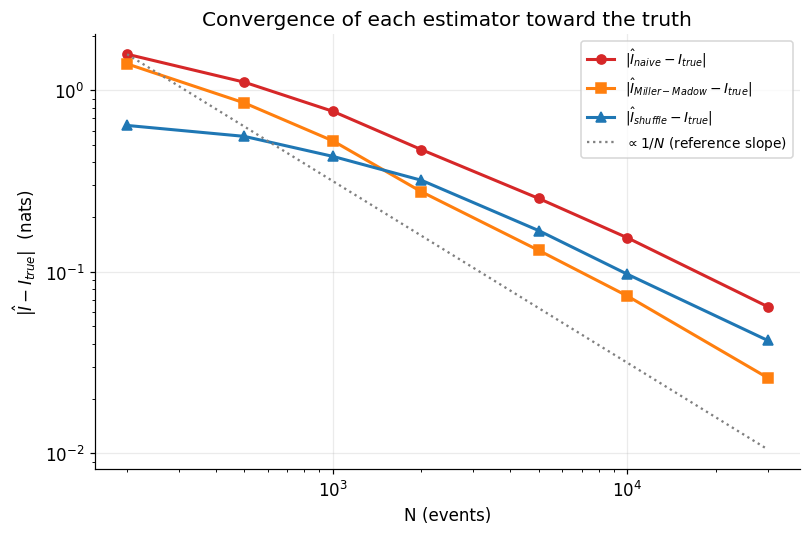

In [10]:

resid_naive = np.abs(np.array(I_naive_arr) - I_ref)
resid_mm    = np.abs(np.array(I_mm_arr)    - I_ref)
resid_sh    = np.abs(np.array(I_sh_arr)    - I_ref)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(N_grid2, resid_naive, 'o-', label=r'$|\hat I_{naive} - I_{true}|$', color=COLOR_NAIVE, lw=2)
ax.loglog(N_grid2, resid_mm,    's-', label=r'$|\hat I_{Miller-Madow} - I_{true}|$', color=COLOR_MM, lw=2)
ax.loglog(N_grid2, resid_sh,    '^-', label=r'$|\hat I_{shuffle} - I_{true}|$', color=COLOR_SH, lw=2)

ref_line = resid_naive[0] * (N_grid2[0] / N_grid2)
ax.loglog(N_grid2, ref_line, ':', color='gray', lw=1.5, label=r'$\propto 1/N$ (reference slope)')

ax.set_xlabel('N (events)')
ax.set_ylabel(r'$|\hat I - I_{true}|$  (nats)')
ax.set_title('Convergence of each estimator toward the truth')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()



Both corrections sit visibly below the naive curve, closer to the true
value at fixed $N$. If the corrected residual curves are roughly parallel
to the naive curve rather than dropping faster, that indicates the
residual error is increasingly dominated by *sub-leading* bias terms that
neither method captures (Miller–Madow: higher-order $1/N^2,\ldots$ terms;
shuffle: the systematic overcorrection discussed above) — exactly the gap
the rigorous fix in Section 6 is designed to close.



## 6. The rigorous fix: NSB Bayesian entropy estimator

Both corrections above are still, fundamentally, **point corrections
derived under a large-$N$ assumption** — they estimate one number (the
bias) and subtract it. The **Nemenman–Shafee–Bialek (NSB)** estimator takes
a genuinely different approach: instead of correcting a biased point
estimate, it computes the **Bayesian posterior mean entropy** directly,
using a prior specifically constructed to avoid smuggling in any implicit
assumption about how spread-out the distribution is. This is the standard
tool for the severely-undersampled regime ($N \lesssim K$) in the
neuroscience spike-train MI literature — precisely our regime once hadron
multiplicities are binned in 2D.

**The construction, in four steps:**

1. Put a symmetric Dirichlet prior $P(p\,|\,\beta)\propto\prod_i p_i^{\beta-1}$
   over the $K$ possible bin probabilities. For any fixed $\beta$, the
   posterior mean entropy given counts $\{n_i\}$ has a closed form:
   $$\langle S\rangle_{\beta,n} = \psi_0(N+K\beta+1) - \sum_i \frac{n_i+\beta}{N+K\beta}\,\psi_0(n_i+\beta+1)$$

2. **The catch:** a flat prior on $\beta$ does *not* give a flat prior on
   entropy — for large $K$, $P(S\,|\,\beta)$ is sharply peaked as a
   function of $\beta$. Fixing any single $\beta$ (as ordinary
   "add-one" / Laplace / Jeffreys smoothing does) silently assumes an
   entropy value before you've even looked at the data.

3. NSB's fix: reweight $\beta$ by the hyperprior that makes the *induced*
   prior on $S$ flat — literally the rate of change of the prior mean
   entropy with $\beta$:
   $$\rho(\beta) = K\,\psi_1(K\beta+1) - \psi_1(\beta+1)$$

4. Average over $\beta$, weighted by both this hyperprior and the
   Dirichlet–multinomial evidence $P(n\,|\,\beta)$ (how well that $\beta$
   explains the observed counts):
   $$\hat S_{\rm NSB} = \frac{\int_0^\infty d\beta\;\rho(\beta)\,P(n\,|\,\beta)\,\langle S\rangle_{\beta,n}}
   {\int_0^\infty d\beta\;\rho(\beta)\,P(n\,|\,\beta)}$$

This reduces to a tractable 1D numerical integral. We apply it separately
to $S_A, S_B, S_{AB}$ (each needs its own alphabet size $K$: for the joint
distribution, $K_{AB}^{\rm alphabet} = K_A^{\rm alphabet}\times K_B^{\rm alphabet}$,
the *full* product space of possible outcomes — not the observed $K_{AB}$
count from before, since NSB needs to know the size of the space being
integrated over, not how much of it happened to be hit), then combine:
$\hat I_{\rm NSB} = \hat S_A^{\rm NSB} + \hat S_B^{\rm NSB} - \hat S_{AB}^{\rm NSB}$.


In [11]:

def nsb_entropy_from_counts(counts_nonzero, K, beta_grid=None):
    '''
    NSB posterior-mean entropy (nats) given the nonzero occupied-bin counts
    and the TOTAL alphabet size K (including unobserved bins).

    counts_nonzero : 1D array of counts for bins that were actually hit
                      (zero-count bins are handled analytically, not passed in)
    K              : total number of possible outcomes (alphabet size)
    '''
    counts_nonzero = np.asarray(counts_nonzero, dtype=float)
    N = counts_nonzero.sum()
    K_obs = len(counts_nonzero)
    K_zero = K - K_obs   # bins with zero observed count

    if beta_grid is None:
        beta_grid = np.logspace(-6, 3, 300)
    b = beta_grid[:, None]          # shape (n_beta, 1)
    c = counts_nonzero[None, :]     # shape (1, K_obs)

    # log Dirichlet-multinomial evidence P(n | beta), vectorized over beta.
    # Zero-count bins contribute gammaln(beta)-gammaln(beta)=0 and are omitted.
    logP = (gammaln(K * b[:, 0]) - gammaln(N + K * b[:, 0]) + gammaln(N + 1)
            - np.sum(gammaln(c + 1), axis=1)
            + np.sum(gammaln(c + b) - gammaln(b), axis=1))

    # posterior mean entropy given beta
    sum_term = (np.sum((c + b) * digamma(c + b + 1), axis=1)
                + K_zero * b[:, 0] * digamma(b[:, 0] + 1))
    S_beta = digamma(N + K * b[:, 0] + 1) - sum_term / (N + K * b[:, 0])

    # NSB hyperprior that flattens the induced prior on S
    rho = K * polygamma(1, K * b[:, 0] + 1) - polygamma(1, b[:, 0] + 1)

    logw = logP + np.log(rho)
    logw -= logw.max()              # numerical stability
    w = np.exp(logw)

    # integrate over beta on a log grid (Jacobian: dbeta = beta * d(log beta))
    t = np.log(beta_grid)
    weight_t = w * beta_grid
    Z = np.trapezoid(weight_t, t)
    S_nsb = np.trapezoid(weight_t * S_beta, t) / Z
    return S_nsb

# Alphabet sizes: generous fixed upper bounds on possible hadron multiplicity
# per jet, comfortably larger than anything actually observed (ref sample
# reaches K_A~159, K_B~147). The joint alphabet is the full product space.
ALPHABET_A, ALPHABET_B = 200, 200
K_JOINT_ALPHABET = ALPHABET_A * ALPHABET_B

def nsb_MI(n_a, n_b):
    va, ca = np.unique(n_a, return_counts=True)
    vb, cb = np.unique(n_b, return_counts=True)
    pairs = np.stack([n_a, n_b], axis=1)
    _, cab = np.unique(pairs, axis=0, return_counts=True)

    S_A_nsb  = nsb_entropy_from_counts(ca,  ALPHABET_A)
    S_B_nsb  = nsb_entropy_from_counts(cb,  ALPHABET_B)
    S_AB_nsb = nsb_entropy_from_counts(cab, K_JOINT_ALPHABET)

    return S_A_nsb + S_B_nsb - S_AB_nsb, dict(S_A=S_A_nsb, S_B=S_B_nsb, S_AB=S_AB_nsb)



### Head-to-head: all four estimators at the same sample sizes


In [12]:

print(f"{'N':>8} | {'I_naive':>9} | {'I_MM':>9} | {'I_shuffle':>10} | {'I_NSB':>9} | {'I_true(ref)':>11}")
print("-"*72)

nsb_table = []
for N in [200, 500, 1000, 2000, 5000, 20000]:
    na, nb = generate_events(N, K_SHAPE, THETA_SCALE, C_CORR)
    I_naive, _ = naive_MI(na, nb)
    I_mm, _, _ = miller_madow_MI(na, nb)
    I_sh, _, _, _ = shuffle_correction_MI(na, nb, n_shuffles=200)
    I_nsb, _ = nsb_MI(na, nb)
    nsb_table.append((N, I_naive, I_mm, I_sh, I_nsb))
    print(f"{N:>8} | {I_naive:>9.4f} | {I_mm:>9.4f} | {I_sh:>10.4f} | {I_nsb:>9.4f} | {I_ref:>11.4f}")


       N |   I_naive |      I_MM |  I_shuffle |     I_NSB | I_true(ref)
------------------------------------------------------------------------
     200 |    2.3511 |    2.1711 |     0.0578 |    0.5098 |      0.7329


     500 |    1.7525 |    1.5035 |     0.2137 |    0.6833 |      0.7329


    1000 |    1.5071 |    1.2711 |     0.3062 |    0.7369 |      0.7329


    2000 |    1.2299 |    1.0367 |     0.4340 |    0.7416 |      0.7329


    5000 |    1.0030 |    0.8842 |     0.5807 |    0.7678 |      0.7329


   20000 |    0.8222 |    0.7716 |     0.6752 |    0.7411 |      0.7329



NSB should track $I_{\rm true}$ closely across the *entire* range, including
at $N=200$ where the naive estimator is off by roughly a factor of three
and Miller–Madow has barely moved. This is the payoff of treating the
whole problem as Bayesian inference over entropy rather than trying to
patch a biased point estimate after the fact.

### Adding NSB to the convergence comparison


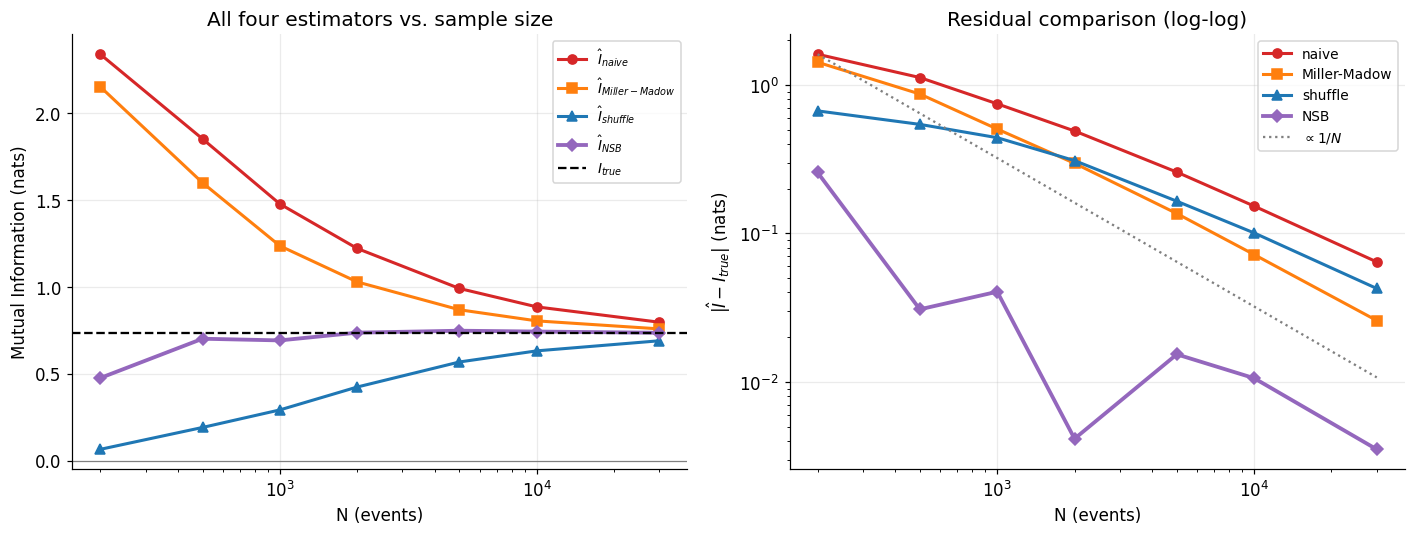

In [13]:

N_grid3 = np.array([200, 500, 1000, 2000, 5000, 10000, 30000])
n_rep3 = 15

I_naive_arr3, I_mm_arr3, I_sh_arr3, I_nsb_arr3 = [], [], [], []

for N in N_grid3:
    naive_reps, mm_reps, sh_reps, nsb_reps = [], [], [], []
    for _ in range(n_rep3):
        na, nb = generate_events(N, K_SHAPE, THETA_SCALE, C_CORR)
        I_naive, _ = naive_MI(na, nb)
        I_mm, _, _ = miller_madow_MI(na, nb)
        I_sh, _, _, _ = shuffle_correction_MI(na, nb, n_shuffles=60)
        I_nsb, _ = nsb_MI(na, nb)
        naive_reps.append(I_naive)
        mm_reps.append(I_mm)
        sh_reps.append(I_sh)
        nsb_reps.append(I_nsb)
    I_naive_arr3.append(np.mean(naive_reps))
    I_mm_arr3.append(np.mean(mm_reps))
    I_sh_arr3.append(np.mean(sh_reps))
    I_nsb_arr3.append(np.mean(nsb_reps))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(N_grid3, I_naive_arr3, 'o-', label=r'$\hat I_{naive}$', color=COLOR_NAIVE, lw=2)
ax.plot(N_grid3, I_mm_arr3,    's-', label=r'$\hat I_{Miller-Madow}$', color=COLOR_MM, lw=2)
ax.plot(N_grid3, I_sh_arr3,    '^-', label=r'$\hat I_{shuffle}$', color=COLOR_SH, lw=2)
ax.plot(N_grid3, I_nsb_arr3,   'D-', label=r'$\hat I_{NSB}$', color=COLOR_NSB, lw=2.5)
ax.axhline(I_ref, color='k', ls='--', lw=1.5, label=r'$I_{true}$')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('N (events)')
ax.set_ylabel('Mutual Information (nats)')
ax.set_title('All four estimators vs. sample size')
ax.legend(fontsize=9)

ax = axes[1]
resid_naive3 = np.abs(np.array(I_naive_arr3) - I_ref)
resid_mm3    = np.abs(np.array(I_mm_arr3)    - I_ref)
resid_sh3    = np.abs(np.array(I_sh_arr3)    - I_ref)
resid_nsb3   = np.abs(np.array(I_nsb_arr3)   - I_ref)

ax.loglog(N_grid3, resid_naive3, 'o-', label=r'naive', color=COLOR_NAIVE, lw=2)
ax.loglog(N_grid3, resid_mm3,    's-', label=r'Miller-Madow', color=COLOR_MM, lw=2)
ax.loglog(N_grid3, resid_sh3,    '^-', label=r'shuffle', color=COLOR_SH, lw=2)
ax.loglog(N_grid3, resid_nsb3,   'D-', label=r'NSB', color=COLOR_NSB, lw=2.5)
ref_line = resid_naive3[0] * (N_grid3[0] / N_grid3)
ax.loglog(N_grid3, ref_line, ':', color='gray', lw=1.5, label=r'$\propto 1/N$')
ax.set_xlabel('N (events)')
ax.set_ylabel(r'$|\hat I - I_{true}|$ (nats)')
ax.set_title('Residual comparison (log-log)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()



NSB's residual curve should sit visibly below all three other methods
across most of the range, and in particular should stay far more stable
at small $N$ — it doesn't need $N\gg K$ to behave sensibly, which is
exactly the regime the other three estimators struggle in.

**Practical notes for using this on the real STAR dijet data:**

- The alphabet size $K$ (for each marginal, and $K_A\times K_B$ for the
  joint) needs to be fixed *before* looking at the data — pick a generous
  fixed upper bound on plausible hadron multiplicity per jet (e.g. from
  detector acceptance / physical kinematic limits), not the observed
  range, or you reintroduce a data-dependent bias through the back door.
- NSB is somewhat more expensive per call than MM or shuffle-subtraction
  (a 1D numerical integral instead of a closed-form correction or a
  handful of permutations), but as shown above it's still a fraction of
  a second per event sample — entirely practical for a real analysis,
  including a full jackknife or bootstrap over your actual dataset for
  uncertainty quantification.
- The same estimator applies directly to $S(B|A)=S_{AB}-S_A$ — swap in
  the NSB entropies there instead of the naive/MM/shuffle versions before
  making any negative-conditional-entropy (quantum) claim, as done next.



## 7. Putting it together: quantum-signal detection sensitivity

Section 2 established $S(B|A)=S_{AB}-S_A$ as the correct, computable
witness (provably $\geq 0$ classically), and Sections 3–6 established that
NSB is the best-behaved bias-corrected estimator, especially at small $N$.
Here we combine both: since our toy model is *itself* purely classical, its
true $S(B|A)$ is a known, solidly positive number — exactly the right
sandbox to measure the **statistical noise floor** of the NSB estimator
against a known ground truth, and turn that into a quantitative statement
about how large a genuine quantum excess would need to be, at a given
event count, to be distinguishable from this noise floor.

**Design:** for a grid of $N$, draw many independent samples from the same
generative model, compute $\hat S(B|A)_{\rm NSB}$ for each, and take the
spread over draws as the estimator's sampling uncertainty
$\sigma_{\rm NSB}(N)$ at that statistics. A hypothetical genuine quantum
excess of magnitude $\Delta$ is then detectable at $z$ standard deviations
once
$$\Delta \;>\; z\,\sigma_{\rm NSB}(N)$$
Equivalently, the **minimum detectable quantum signal** at a chosen
confidence level ($z=3$ below is a common "solid evidence" threshold) is
$\Delta_{\rm min}(N) = z\,\sigma_{\rm NSB}(N)$.

*(In a real analysis with one actual dataset — not a synthetic model with
known truth — you'd estimate $\sigma_{\rm NSB}(N)$ directly from that
dataset via bootstrap or jackknife resampling, rather than generating
independent Monte Carlo replicates as we do here for demonstration.)*


In [14]:

def sba_estimates(n_a, n_b):
    '''Return (naive, Miller-Madow, NSB) estimates of S(B|A) = S_AB - S_A.'''
    S_A_naive, S_B_naive, S_AB_naive, K_A, K_B, K_AB, N = entropies_from_samples(n_a, n_b)
    SBA_naive = S_AB_naive - S_A_naive

    # Miller-Madow: each entropy corrected independently (no product-approx
    # pitfall here, since we're not combining three terms multiplicatively).
    S_A_mm  = S_A_naive  - (K_A  - 1) / (2.0 * N)
    S_AB_mm = S_AB_naive - (K_AB - 1) / (2.0 * N)
    SBA_mm  = S_AB_mm - S_A_mm

    # NSB
    _, nsb_info = nsb_MI(n_a, n_b)
    SBA_nsb = nsb_info['S_AB'] - nsb_info['S_A']

    return SBA_naive, SBA_mm, SBA_nsb

# "true" classical S(B|A) from the huge reference sample (bias negligible at N=5e6)
S_A_ref  = shannon_entropy(np.unique(na_ref, return_counts=True)[1])
S_AB_ref = shannon_entropy(np.unique(np.stack([na_ref, nb_ref], axis=1), axis=0, return_counts=True)[1])
SBA_ref  = S_AB_ref - S_A_ref
print(f"Reference (true, classical) S(B|A) = {SBA_ref:.4f} nats  (solidly positive, as required classically)")


Reference (true, classical) S(B|A) = 3.1524 nats  (solidly positive, as required classically)



### Noise floor: NSB sampling uncertainty of $S(B|A)$ vs. $N$


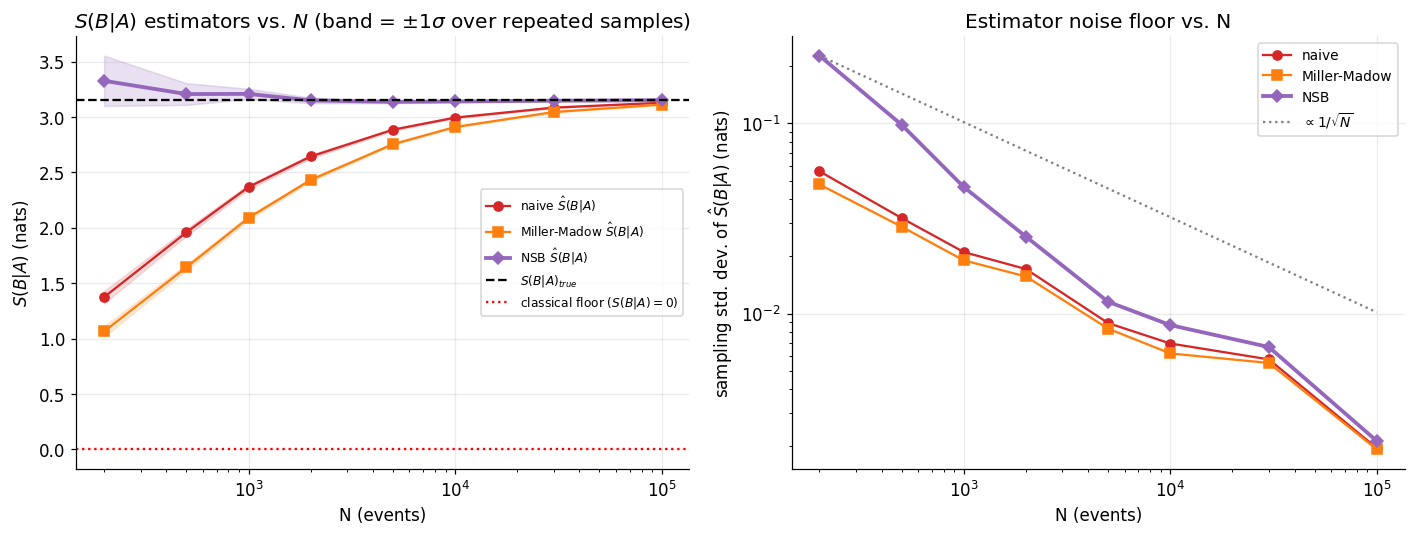

In [15]:

N_grid4 = np.array([200, 500, 1000, 2000, 5000, 10000, 30000, 100000])
n_rep4 = 25

sba_naive_mean, sba_naive_std = [], []
sba_mm_mean,    sba_mm_std    = [], []
sba_nsb_mean,   sba_nsb_std   = [], []

for N in N_grid4:
    naive_reps, mm_reps, nsb_reps = [], [], []
    for _ in range(n_rep4):
        na, nb = generate_events(N, K_SHAPE, THETA_SCALE, C_CORR)
        sba_naive, sba_mm, sba_nsb = sba_estimates(na, nb)
        naive_reps.append(sba_naive)
        mm_reps.append(sba_mm)
        nsb_reps.append(sba_nsb)
    sba_naive_mean.append(np.mean(naive_reps)); sba_naive_std.append(np.std(naive_reps))
    sba_mm_mean.append(np.mean(mm_reps));       sba_mm_std.append(np.std(mm_reps))
    sba_nsb_mean.append(np.mean(nsb_reps));     sba_nsb_std.append(np.std(nsb_reps))

sba_naive_mean, sba_naive_std = np.array(sba_naive_mean), np.array(sba_naive_std)
sba_mm_mean,    sba_mm_std    = np.array(sba_mm_mean),    np.array(sba_mm_std)
sba_nsb_mean,   sba_nsb_std   = np.array(sba_nsb_mean),   np.array(sba_nsb_std)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.fill_between(N_grid4, sba_naive_mean-sba_naive_std, sba_naive_mean+sba_naive_std, color=COLOR_NAIVE, alpha=0.15)
ax.plot(N_grid4, sba_naive_mean, 'o-', color=COLOR_NAIVE, label=r'naive $\hat S(B|A)$')
ax.fill_between(N_grid4, sba_mm_mean-sba_mm_std, sba_mm_mean+sba_mm_std, color=COLOR_MM, alpha=0.15)
ax.plot(N_grid4, sba_mm_mean, 's-', color=COLOR_MM, label=r'Miller-Madow $\hat S(B|A)$')
ax.fill_between(N_grid4, sba_nsb_mean-sba_nsb_std, sba_nsb_mean+sba_nsb_std, color=COLOR_NSB, alpha=0.2)
ax.plot(N_grid4, sba_nsb_mean, 'D-', color=COLOR_NSB, lw=2.5, label=r'NSB $\hat S(B|A)$')
ax.axhline(SBA_ref, color='k', ls='--', lw=1.5, label=r'$S(B|A)_{true}$')
ax.axhline(0, color='red', lw=1.5, ls=':', label='classical floor ($S(B|A)=0$)')
ax.set_xscale('log')
ax.set_xlabel('N (events)')
ax.set_ylabel(r'$S(B|A)$ (nats)')
ax.set_title(r'$S(B|A)$ estimators vs. $N$ (band = $\pm 1\sigma$ over repeated samples)')
ax.legend(fontsize=8)

ax = axes[1]
ax.loglog(N_grid4, sba_naive_std, 'o-', color=COLOR_NAIVE, label='naive')
ax.loglog(N_grid4, sba_mm_std,    's-', color=COLOR_MM,    label='Miller-Madow')
ax.loglog(N_grid4, sba_nsb_std,   'D-', color=COLOR_NSB,   lw=2.5, label='NSB')
ref_slope = sba_nsb_std[0] * np.sqrt(N_grid4[0] / N_grid4)
ax.loglog(N_grid4, ref_slope, ':', color='gray', label=r'$\propto 1/\sqrt{N}$')
ax.set_xlabel('N (events)')
ax.set_ylabel(r'sampling std. dev. of $\hat S(B|A)$ (nats)')
ax.set_title('Estimator noise floor vs. N')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()



NSB has both the smallest bias (its mean tracks $S(B|A)_{\rm true}$ most
closely, especially at small $N$) *and* — importantly for this question —
its noise floor shrinks cleanly as $N$ grows, roughly following the
standard $1/\sqrt{N}$ statistical scaling. That clean scaling is what lets
us turn this into a concrete detection-sensitivity statement.

### Minimum detectable quantum signal vs. $N$


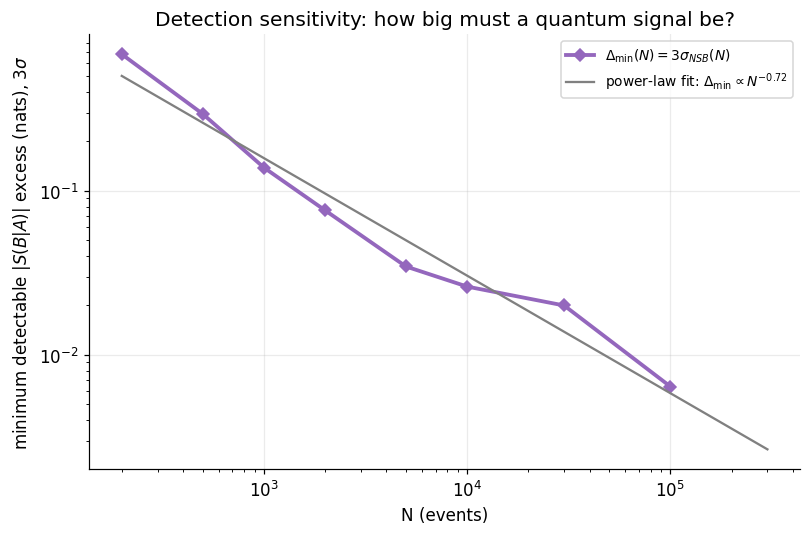

    assumed |quantum signal| |   N needed for 3-sigma detection
---------------------------------------------------------------
                     0.500  nats |                            201
                     0.200  nats |                            722
                     0.100  nats |                          1,899
                     0.050  nats |                          4,995
                     0.020  nats |                         17,934
                     0.010  nats |                         47,164


In [16]:

Z_SIGMA = 3.0   # "solid evidence" threshold

delta_min = Z_SIGMA * sba_nsb_std

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(N_grid4, delta_min, 'D-', color=COLOR_NSB, lw=2.5,
          label=rf'$\Delta_{{\rm min}}(N) = {Z_SIGMA:.0f}\sigma_{{NSB}}(N)$')

# power-law fit for interpolation/extrapolation: log(delta) = a + b*log(N)
coeffs = np.polyfit(np.log(N_grid4), np.log(delta_min), 1)
N_fit = np.logspace(np.log10(N_grid4[0]), np.log10(N_grid4[-1]*3), 100)
delta_fit = np.exp(np.polyval(coeffs, np.log(N_fit)))
ax.loglog(N_fit, delta_fit, '-', color='gray', lw=1.5,
          label=rf'power-law fit: $\Delta_{{\rm min}}\propto N^{{{coeffs[0]:.2f}}}$')

ax.set_xlabel('N (events)')
ax.set_ylabel(r'minimum detectable $|S(B|A)|$ excess (nats), $3\sigma$')
ax.set_title('Detection sensitivity: how big must a quantum signal be?')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Invert the fit: for a few illustrative candidate signal sizes, what N is needed?
print(f"{'assumed |quantum signal|':>28} | {'N needed for 3-sigma detection':>32}")
print("-"*63)
for delta_target in [0.5, 0.2, 0.1, 0.05, 0.02, 0.01]:
    log_N_needed = (np.log(delta_target) - coeffs[1]) / coeffs[0]
    N_needed = np.exp(log_N_needed)
    print(f"{delta_target:>26.3f}  nats | {N_needed:>30,.0f}")



This is the direct, quantitative answer to "how big must a quantum signal
be, at a given statistics, to be believable": given the fitted
$1/\sqrt{N}$ scaling of the NSB noise floor, a candidate quantum-correlation
excess needs to exceed the $\Delta_{\rm min}(N)$ curve to be called a
$3\sigma$ detection at that statistics — and the table inverts this into
"how many events do I need" for a few illustrative signal sizes.

**Caveats to carry into the real analysis:**

- $\sigma_{\rm NSB}(N)$ here is measured *at the true classical value*
  ($S(B|A)_{\rm true}\approx$ a few nats for our toy correlation strength),
  not at the boundary $S(B|A)=0$. Entropy-estimator variance depends on
  the shape of the underlying distribution, not just $N$, so the true
  noise floor near a genuinely small or slightly-negative $S(B|A)$ could
  differ somewhat from this estimate. For the real STAR data, re-run this
  same bootstrap procedure centered on the *actual* observed operating
  point (via jackknife/bootstrap on the real dataset itself), rather than
  trusting this toy-model number directly.
- This procedure characterizes sensitivity to a violation of the
  *classical* conditional-entropy bound using multiplicity data alone
  (Section 2). It is not a substitute for an actual quantum witness such
  as a Bell/CHSH inequality on the $\Lambda\bar\Lambda$ spin observables,
  which remains the model-independent way to certify entanglement rather
  than merely rule out one particular classical description.



## 8. Summary and recommendations for the real STAR dijet analysis

1. **The correct witness** is $S(B|A)=S_{AB}-S_A$ (and $S(A|B)$, check
   both directions), which must be $\geq 0$ for any classical distribution.
   Genuine quantum discord (Ollivier–Zurek) cannot be computed from
   hadron-count histograms alone — any classical joint distribution
   trivially gives discord $=0$; it would require actual quantum-state
   tomography (e.g. the $\Lambda\bar\Lambda$ spin-density-matrix channel).

2. **The naive plug-in MI estimator is always biased upward**, with
   leading term $\approx (K_{AB}-K_A-K_B+1)/(2N)$. Coarser binning or fewer
   events both make it worse — comparing different STAR running periods,
   luminosities, or binning choices will report different central MI
   values from what should be the same physics, purely from this effect.

3. **Miller–Madow** (done correctly, using the *observed* $K_{AB}$, not
   the product $K_AK_B$) and **shuffle-subtraction** both substantially
   reduce this bias and stay well-behaved, but neither is exact at small
   $N$: Miller–Madow is a first-order truncation; shuffle-subtraction
   tends to systematically *overcorrect* when the true correlation is
   strong.

4. **NSB** is the recommended estimator for the real analysis: a Bayesian
   posterior-mean entropy built on a prior specifically constructed to be
   uninformative about entropy itself. It tracks the truth closely across
   the entire tested $N$ range, including deep in the severely-undersampled
   regime where the other methods struggle, at a modest computational cost.

5. **Before claiming any quantum-correlation excess**, bias-correct with
   NSB and compare against the estimator's own sampling noise floor at
   that $N$ (bootstrapped from the real dataset via jackknife/bootstrap,
   not assumed from this toy model). Section 7 works this out
   quantitatively: the NSB noise floor shrinks $\propto 1/\sqrt N$, giving
   a concrete minimum-detectable-signal curve
   $\Delta_{\rm min}(N)=z\,\sigma_{\rm NSB}(N)$ — a direct, quotable answer
   to "how big must a genuine quantum excess be, at a given event count,
   to be distinguishable from finite-sample bias and noise."

6. **This entire procedure only tests a violation of the classical
   conditional-entropy bound.** It is a necessary check before any
   stronger quantum claim, but is not itself a model-independent
   entanglement certification — that role is played by the
   Bell/CHSH-type inequality on spin observables in the parallel
   $\Lambda\bar\Lambda$ program.
